# Module 5 Assignment Analysis
Anjali Khatri <br>
INST414 <br>
8/21/2026 <br>

In [13]:
# module  imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from io import BytesIO

from scipy.sparse import lil_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [4]:
#read in data
df = pd.read_csv("daily_aqi_by_county_2026.csv")
print("Rows and columns:", df.shape)
df.head()

Rows and columns: (77795, 10)


,State Name,county Name,State Code,County Code,Date,AQI,Category,Defining Parameter,Defining Site,Number of Sites Reporting
0,Alabama,Baldwin,1,3,2026-01-01,65,Moderate,PM2.5,01-003-0010,1
1,Alabama,Baldwin,1,3,2026-01-02,25,Good,PM2.5,01-003-0010,1
2,Alabama,Baldwin,1,3,2026-01-03,40,Good,PM2.5,01-003-0010,1
3,Alabama,Baldwin,1,3,2026-01-04,39,Good,PM2.5,01-003-0010,1
4,Alabama,Baldwin,1,3,2026-01-05,41,Good,PM2.5,01-003-0010,1


In [5]:
# data
print(df.columns.tolist())
print(df.isna().sum())

df[[
    "Date",
    "State Name",
    "county Name",
    "AQI",
    "Category",
    "Defining Parameter",
    "Number of Sites Reporting"
]].head()

['State Name', 'county Name', 'State Code', 'County Code', 'Date', 'AQI', 'Category', 'Defining Parameter', 'Defining Site', 'Number of Sites Reporting']
State Name                   0
county Name                  0
State Code                   0
County Code                  0
Date                         0
AQI                          0
Category                     0
Defining Parameter           0
Defining Site                0
Number of Sites Reporting    0
dtype: int64


,Date,State Name,county Name,AQI,Category,Defining Parameter,Number of Sites Reporting
0,2026-01-01,Alabama,Baldwin,65,Moderate,PM2.5,1
1,2026-01-02,Alabama,Baldwin,25,Good,PM2.5,1
2,2026-01-03,Alabama,Baldwin,40,Good,PM2.5,1
3,2026-01-04,Alabama,Baldwin,39,Good,PM2.5,1
4,2026-01-05,Alabama,Baldwin,41,Good,PM2.5,1


In [9]:
# review missing values

print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))

df[
    [
        "Date",
        "State Name",
        "county Name",
        "AQI",
        "Category",
        "Defining Parameter",
        "Number of Sites Reporting"
    ]
].head()

Columns:
['State Name', 'county Name', 'State Code', 'County Code', 'Date', 'AQI', 'Category', 'Defining Parameter', 'Defining Site', 'Number of Sites Reporting', 'unhealthy_day', 'month', 'day_of_year']

Missing values:
State Name                   0
county Name                  0
State Code                   0
County Code                  0
Date                         0
AQI                          0
Category                     0
Defining Parameter           0
Defining Site                0
Number of Sites Reporting    0
unhealthy_day                0
month                        0
day_of_year                  0
dtype: int64


,Date,State Name,county Name,AQI,Category,Defining Parameter,Number of Sites Reporting
0,2026-01-01,Alabama,Baldwin,65,Moderate,PM2.5,1
1,2026-01-02,Alabama,Baldwin,25,Good,PM2.5,1
2,2026-01-03,Alabama,Baldwin,40,Good,PM2.5,1
3,2026-01-04,Alabama,Baldwin,39,Good,PM2.5,1
4,2026-01-05,Alabama,Baldwin,41,Good,PM2.5,1


In [10]:
# clean data
# Unhealthy day: AQI >= 101
# 0 = Good or Moderate
# 1 = Unhealthy for Sensitive Groups or worse


df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df = df.dropna(subset=["Date", "AQI"]).copy()

df["unhealthy_day"] = (df["AQI"] >= 101).astype(int)

df["month"] = df["Date"].dt.month
df["day_of_year"] = df["Date"].dt.dayofyear

df["Defining Parameter"] = (
    df["Defining Parameter"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

df["Number of Sites Reporting"] = (
    df["Number of Sites Reporting"]
    .fillna(df["Number of Sites Reporting"].median())
)

print(df["unhealthy_day"].value_counts())

unhealthy_day
0    77480
1      315
Name: count, dtype: int64


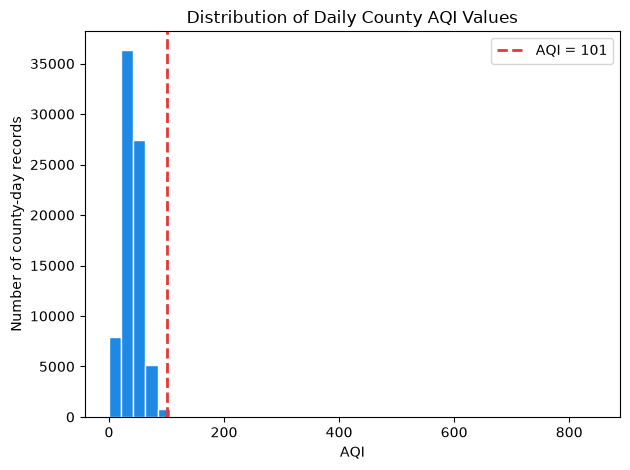

In [ ]:
# AQI distribution

plt.hist(
    df["AQI"],
    bins=40,
    color="#1E88E5",
    edgecolor="white"
)

plt.axvline(
    101,
    color="#E53935",
    linestyle="--",
    linewidth=2,
    label="AQI = 101"
)

plt.title("Distribution of Daily County AQI Values")
plt.xlabel("AQI")
plt.ylabel("Number of county-day records")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
# Clustering

numeric_features = [
    "AQI",
    "month",
    "Number of Sites Reporting"
]

categorical_features = [
    "Defining Parameter"
]

feature_columns = numeric_features + categorical_features

feature_df = df[feature_columns].copy()

feature_df.head()

,AQI,month,Number of Sites Reporting,Defining Parameter
0,65,1,1,PM2.5
1,25,1,1,PM2.5
2,40,1,1,PM2.5
3,39,1,1,PM2.5
4,41,1,1,PM2.5


In [29]:
#feeature matrix
numeric_features = [
    "AQI",
    "month",
    "Number of Sites Reporting"
]

pollutants = sorted(
    df["Defining Parameter"]
    .dropna()
    .unique()
)

pollutant_to_column = {
    pollutant: index
    for index, pollutant in enumerate(pollutants)
}

print("Numeric features:", numeric_features)
print("Pollutant categories:", pollutants)
print("Number of pollutant columns:", len(pollutant_to_column))

scaler = StandardScaler()

scaled_numeric = scaler.fit_transform(
    df[numeric_features]
)
print("Scaled numeric matrix shape:", scaled_numeric.shape)

Numeric features: ['AQI', 'month', 'Number of Sites Reporting']
Pollutant categories: ['CO', 'NO2', 'Ozone', 'PM10', 'PM2.5']
Number of pollutant columns: 5
Scaled numeric matrix shape: (77795, 3)


In [30]:
#sparse feature martix
number_of_rows = len(df)
number_of_numeric_features = len(numeric_features)
number_of_pollutants = len(pollutant_to_column)

number_of_columns = (
    number_of_numeric_features +
    number_of_pollutants
)

feature_matrix = lil_matrix(
    (number_of_rows, number_of_columns),
    dtype=float
)

print("Sparse feature matrix shape:", feature_matrix.shape)

Sparse feature matrix shape: (77795, 8)


In [31]:
for row_index in range(number_of_rows):
    for numeric_index in range(number_of_numeric_features):
        feature_matrix[row_index, numeric_index] = (
            scaled_numeric[row_index, numeric_index]
        )

In [32]:
for row_index, pollutant in enumerate(
    df["Defining Parameter"]
):
    pollutant_index = pollutant_to_column[pollutant]

    matrix_column = (
        number_of_numeric_features +
        pollutant_index
    )

    feature_matrix[row_index, matrix_column] = 1

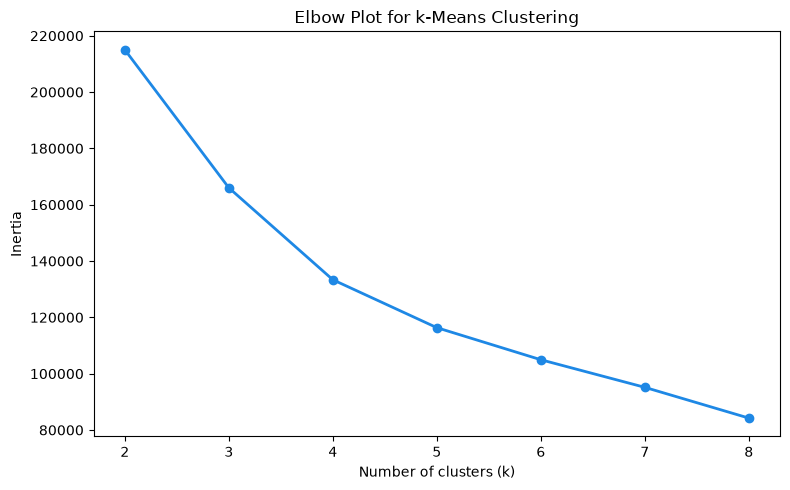

In [34]:
# elbow pllot

inertia_values = []
k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(feature_matrix)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertia_values,
    marker="o",
    color="#1E88E5",
    linewidth=2
)

plt.title("Elbow Plot for k-Means Clustering")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))

plt.tight_layout()
plt.show()

use k = 4 for k means clustering

In [36]:
#k means clustering
k = 4

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(feature_matrix)

df[
    [
        "Date",
        "State Name",
        "county Name",
        "AQI",
        "Defining Parameter",
        "Number of Sites Reporting",
        "cluster"
    ]
].head()

,Date,State Name,county Name,AQI,Defining Parameter,Number of Sites Reporting,cluster
0,2026-01-01,Alabama,Baldwin,65,PM2.5,1,2
1,2026-01-02,Alabama,Baldwin,25,PM2.5,1,1
2,2026-01-03,Alabama,Baldwin,40,PM2.5,1,1
3,2026-01-04,Alabama,Baldwin,39,PM2.5,1,1
4,2026-01-05,Alabama,Baldwin,41,PM2.5,1,1


In [37]:
#cluster summary

cluster_summary = (
    df
    .groupby("cluster")
    .agg(
        records=("AQI", "size"),
        average_aqi=("AQI", "mean"),
        minimum_aqi=("AQI", "min"),
        maximum_aqi=("AQI", "max"),
        average_month=("month", "mean"),
        average_reporting_sites=(
            "Number of Sites Reporting",
            "mean"
        )
    )
    .round(2)
    .sort_values("average_aqi")
)

most_common_pollutant = (
    df
    .groupby("cluster")["Defining Parameter"]
    .agg(lambda values: values.mode().iloc[0])
    .rename("most_common_pollutant")
)

cluster_summary = cluster_summary.join(most_common_pollutant)

cluster_summary

,records,average_aqi,minimum_aqi,maximum_aqi,average_month,average_reporting_sites,most_common_pollutant
cluster,,,,,,,
1,28920,29.49,0,51,1.58,1.40,PM2.5
0,28172,40.71,0,108,3.67,1.50,Ozone
3,1725,57.88,24,846,2.13,14.26,PM2.5
2,18978,58.20,33,729,2.00,2.04,PM2.5


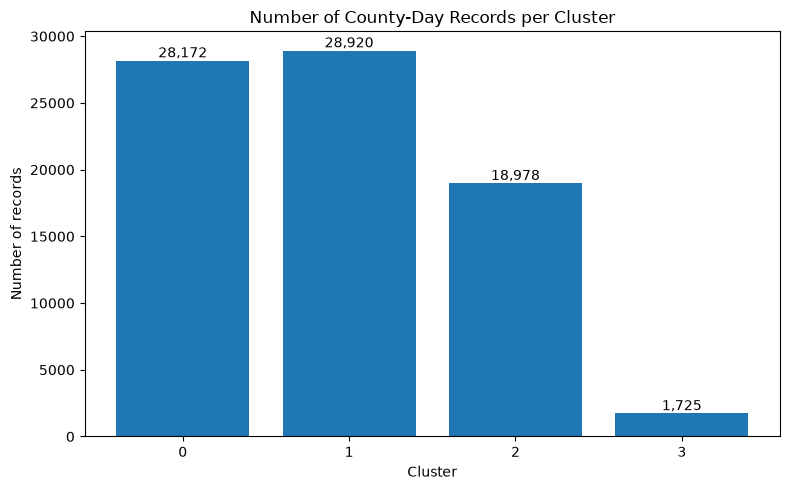

In [39]:
cluster_counts = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.title("Number of County-Day Records per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of records")

for cluster, count in cluster_counts.items():
    plt.text(
        cluster,
        count,
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [40]:
# five records from every cluster

examples = (
    df
    .groupby("cluster", group_keys=False)
    .apply(
        lambda group: group.sample(
            n=min(5, len(group)),
            random_state=42
        )
    )
)

examples[
    [
        "cluster",
        "Date",
        "State Name",
        "county Name",
        "AQI",
        "Category",
        "Defining Parameter",
        "Number of Sites Reporting"
    ]
].sort_values(["cluster", "AQI"])

C:\Users\akhatri\AppData\Local\Temp\ipykernel_31352\759673614.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,cluster,Date,State Name,county Name,AQI,Category,Defining Parameter,Number of Sites Reporting
24706,0,2026-05-25,Iowa,Johnson,32,Good,PM2.5,1
22639,0,2026-04-28,Indiana,Perry,35,Good,Ozone,1
20014,0,2026-03-12,Indiana,Bartholomew,40,Good,Ozone,2
27471,0,2026-03-19,Kentucky,Carter,44,Good,Ozone,1
3922,0,2026-04-06,California,Inyo,58,Moderate,Ozone,1
76204,1,2026-03-01,Wisconsin,Sauk,23,Good,PM2.5,1
72715,1,2026-02-07,Washington,Columbia,26,Good,PM2.5,1
34358,1,2026-01-11,Massachusetts,Barnstable,30,Good,Ozone,1
35252,1,2026-02-03,Michigan,Bay,37,Good,PM2.5,1
3258,1,2026-01-08,California,Butte,38,Good,Ozone,3
